# Climate Change Data Analysis

Author: Tom Rowan, st20285213

## Introduction

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

## Import Libraries

In [770]:
# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# SciKit Learn
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

# Seaborn Graphs
import seaborn as sb

# Plotly
import chart_studio
import plotly.figure_factory as ff
import chart_studio.plotly as py
import plotly.graph_objects as go
import plotly.express as px

# Other Standard Libraries
import os
import re
import json
from urllib import request

## Are we online?

A free account is required to utilise PlotLy graphs, and will require live Internet access to run this notebook properly.

If you are not online, the notebook will display pre-generated png files of the intended output for these graphs.

In [771]:
online = False

def internet_connection():
    try:
        request.urlopen('http://connectivitycheck.gstatic.com/generate_204', timeout=3)
        return True
    except request.URLError as err:
        return False
    
if internet_connection() == True:
    print ("We are online. :)")
    online = True
    
    # Initialise Plotly with credentials
    plotly_username = 'st20285213' 
    plotly_key = 'WiFyUClTkfEwCduNDlpU'     # <-- Note to self, regenerate new key after August 2024
    chart_studio.tools.set_credentials_file(username=plotly_username, api_key=plotly_key) 
else:
    print ("No internet connection, will use pre-generated graphs/tables.")

We are online. :)


In [772]:
# Import my utility library file
import utils
from utils import graph_colours as graph_colours

## Task 1 - Import and Preprocess Data Sets

Task 1:
- i.	Download the dataset from the above link. 
- ii.	Do the necessary preprocessing for example i.e., check for any null value or outlier. If found replace that with mean value and delete repeating factors as necessary.


Reference: https://databank.worldbank.org/reports.aspx?source=2&Topic=19#advancedDownloadOptions

Accessed: 10/05/2024

Reference: https://ourworldindata.org/world-region-map-definitions

Accessed:  15/05/2024



## Countries and Region Dataset

The World Bank provides a simple dataset which classifies each country by region. This data will be used to enrich analysis of the main datasets.

To explore the relative size of the regions, I have performed a count and drawn a graph.

https://unstats.un.org/unsd/methodology/m49/overview/

In [773]:
# Load Data Set
countries_df = pd.read_csv('../datasets/countries/unsd-countrycodes.csv', delimiter=";")

# Rename Columns
countries_df.rename(columns={'Country or Area': 'Country', 'Region Name': 'Region', 'ISO-alpha3 Code': 'ISOcode','Sub-region Name': 'Subregion','Intermediate Region Name': 'Intregion'}, inplace=True)

# Fill in blanks with a zero.
countries_df = countries_df.fillna(0)

# The subregion and intermediate regions are combined, using the more localised 'Intermediate region' in preference.
countries_df['Intregion'] = np.where(countries_df['Intregion'] == 0, countries_df['Subregion'], countries_df['Intregion'])

# Remove the Subregion column and all others not required, and rename with Intregion
countries_df = countries_df.loc[:, ['Country','Region','ISOcode','Intregion']]
countries_df.rename(columns={'Intregion': 'Subregion'}, inplace=True)

# Manually Label Antartica
countries_df.loc[countries_df['Country'] == "Antarctica", "Region"] = "Antarctica"
countries_df.loc[countries_df['Country'] == "Antarctica", "Subregion"] = "Antarctica"



In [774]:
# Produce Lists
countries = list(countries_df['Country'].astype(str).unique())
regions = list(countries_df['Region'].astype(str).unique())
subregions = list(countries_df['Subregion'].astype(str).unique())
country_codes = list(countries_df['ISOcode'].astype(str).unique())

# Sort these...

print (f"Regions ({len(regions)}): {regions}")
print ()
print (f"Subregions ({len(subregions)}): {subregions}")
print ()
print (f"Countries ({len(countries)}): {countries}")

Regions (6): ['Africa', 'Americas', 'Antarctica', 'Asia', 'Europe', 'Oceania']

Subregions (23): ['Northern Africa', 'Eastern Africa', 'Middle Africa', 'Southern Africa', 'Western Africa', 'Caribbean', 'Central America', 'South America', 'Northern America', 'Antarctica', 'Central Asia', 'Eastern Asia', 'South-eastern Asia', 'Southern Asia', 'Western Asia', 'Eastern Europe', 'Northern Europe', 'Southern Europe', 'Western Europe', 'Australia and New Zealand', 'Melanesia', 'Micronesia', 'Polynesia']

Countries (248): ['Algeria', 'Egypt', 'Libya', 'Morocco', 'Sudan', 'Tunisia', 'Western Sahara', 'British Indian Ocean Territory', 'Burundi', 'Comoros', 'Djibouti', 'Eritrea', 'Ethiopia', 'French Southern Territories', 'Kenya', 'Madagascar', 'Malawi', 'Mauritius', 'Mayotte', 'Mozambique', 'Réunion', 'Rwanda', 'Seychelles', 'Somalia', 'South Sudan', 'Uganda', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe', 'Angola', 'Cameroon', 'Central African Republic', 'Chad', 'Congo', 'Democratic Repub

In [775]:
region_count_table = countries_df[['Country','Region']].groupby(['Region'])['Country'].count()
print (region_count_table)
print ()
subregion_count_table = countries_df[['Country','Subregion']].groupby(['Subregion'])['Country'].count()
print (subregion_count_table)


Region
Africa        60
Americas      57
Antarctica     1
Asia          50
Europe        51
Oceania       29
Name: Country, dtype: int64

Subregion
Antarctica                    1
Australia and New Zealand     6
Caribbean                    28
Central America               8
Central Asia                  5
Eastern Africa               22
Eastern Asia                  7
Eastern Europe               10
Melanesia                     5
Micronesia                    8
Middle Africa                 9
Northern Africa               7
Northern America              5
Northern Europe              16
Polynesia                    10
South America                16
South-eastern Asia           11
Southern Africa               5
Southern Asia                 9
Southern Europe              16
Western Africa               17
Western Asia                 18
Western Europe                9
Name: Country, dtype: int64


Text(0, 0.5, 'Number of Countries')

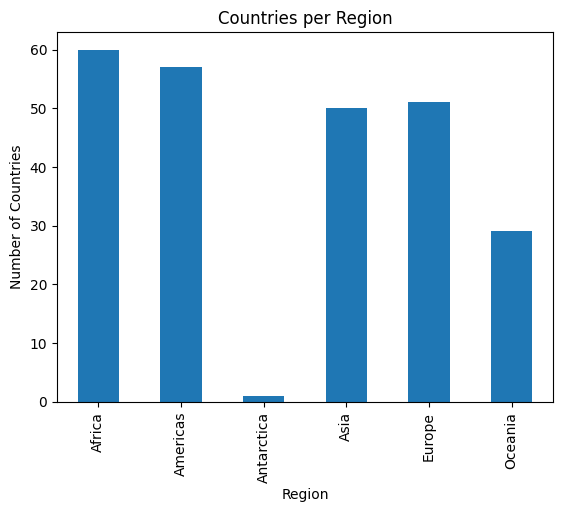

In [776]:
# Ref: https://docs.python.org/3/library/stdtypes.html
# Ref: https://matplotlib.org/stable/users/explain/colors/colormaps.html

region_count_graph = region_count_table.plot(kind='bar', title='Countries per Region', stacked=True)
region_count_graph.set_xlabel('Region')
region_count_graph.set_ylabel('Number of Countries')



Text(0, 0.5, 'Number of Countries')

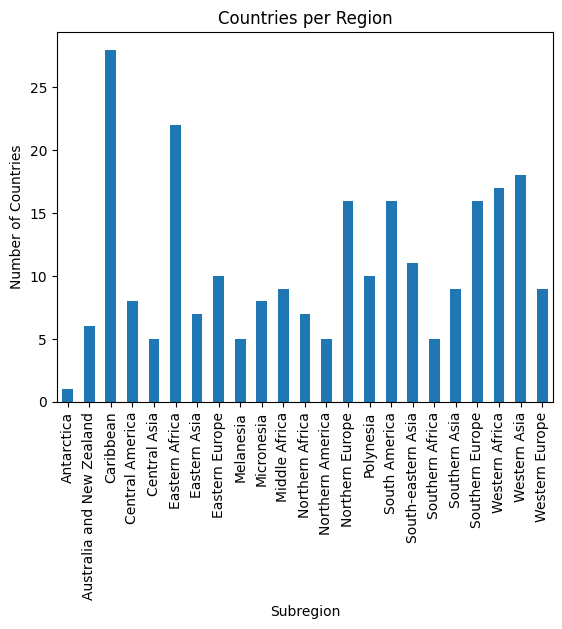

In [777]:
subregion_count_graph = subregion_count_table.plot(kind='bar', title='Countries per Region', stacked=True)
subregion_count_graph.set_xlabel('Subregion')
subregion_count_graph.set_ylabel('Number of Countries')

## Mapping these Regions



Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| countries_df | Country,Code,Region | Pandas DF |
| countries | Country Names | List |
| regions | Region Names | List |
| subregions | Subregion Names | List |
| country_codes | Country Codes | List |

## World Bank Development Indicator Data

I am attempting to explore how land usage affects climate change. The World Bank Development Indicators dataset includes use of land, electricity generation methods and volumes of CO2 produced by source.

In [778]:
# To fetch via a URL, use varible: utils.dev_indic_csv_url

# Load Data Set - Bottom 5 rows are blank or not data.
devindic_df = pd.read_csv('../datasets/wbank_dev_indicators/P_Data_Extract_From_World_Development_Indicators.csv',skipfooter=5, engine='python')

# Drop columns with No data
devindic_df.drop("2022 [YR2022]",axis=1,inplace=True)
devindic_df.drop("2023 [YR2023]",axis=1,inplace=True)
devindic_df.columns

Index(['Series Name', 'Series Code', 'Country Name', 'Country Code',
       '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]',
       '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]',
       '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]',
       '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]',
       '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]',
       '2020 [YR2020]', '2021 [YR2021]'],
      dtype='object')

In [779]:
# Rename Columns to more useful names
numerical_fields = [str(x).zfill(2) for x in range(2000,2022)]
string_fields = ["Series", "SeriesCode", "Country_WB", "ISOcode"]   # <-- Country_WB for WorldBank name, allows merge later
devindic_df.columns = (string_fields + numerical_fields)

devindic_df.columns


Index(['Series', 'SeriesCode', 'Country_WB', 'ISOcode', '2000', '2001', '2002',
       '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011',
       '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
       '2021'],
      dtype='object')

In [780]:
# Reorder dataset by sers code and ISOcode
#devindic_df = devindic_df.sort_values(by=['SeriesCode', 'ISOcode'])

In [781]:
# Define lists
series_codes = (list(devindic_df['SeriesCode'].astype(str).unique()))
series_names = (list(devindic_df['Series'].astype(str).unique()))


In [782]:


# Extract Dataset containing Series Information
table_df = pd.DataFrame()


table_df['SeriesCode'] = devindic_df['SeriesCode'].unique()
table_df['Series'] = devindic_df['Series'].unique()

table_df = table_df.sort_values(by='SeriesCode')

# Re-enable

# table = ff.create_table(table_df)
# py.iplot(table)


In [783]:
print(devindic_df.shape)

(23142, 26)


In [784]:
devindic_df.tail()

,Series,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
23137,Total fisheries production (metric tons),ER.FSH.PROD.MT,Sub-Saharan Africa,SSF,5199488.91,5297800.56,5347826.83,5614839.25,5811742.65,5767348.54,...,6833269.53,6749612.66,7136488.29,7277530.36,7431838.25,7974276.35,7895407.33,7961915,7826265.76,8180272.73
23138,Total fisheries production (metric tons),ER.FSH.PROD.MT,Sub-Saharan Africa (excluding high income),SSA,5166285.91,5243927.56,5284209.83,5527735.25,5709896.65,5657896.54,...,6764582.49,6675649.56,7061088.89,7172175.19,7304290.5,7831623.18,7748783.85,7819745.6,7686618.17,8041098.57
23139,Total fisheries production (metric tons),ER.FSH.PROD.MT,Sub-Saharan Africa (IDA & IBRD countries),TSS,5199488.91,5297800.56,5347826.83,5614839.25,5811742.65,5767348.54,...,6833269.53,6749612.66,7136488.29,7277530.36,7431838.25,7974276.35,7895407.33,7961915,7826265.76,8180272.73
23140,Total fisheries production (metric tons),ER.FSH.PROD.MT,Upper middle income,UMC,71078889.4,69156430.7,71856148.68,71218867.45,77202528.29,78992995.91,...,89571191.51,93263307.37,94005749.25,97657119.11,99408754.95,101594266.52,106297663.06,105787856.91,108038766.6,111435146.39
23141,Total fisheries production (metric tons),ER.FSH.PROD.MT,World,WLD,137012144.68,136763113.54,140159792.35,140238806.47,149082261.24,151975436.07,...,177010760.37,184950306,190204141.08,195700784.41,197685290.2,205148563.7,211435206.37,211656620.38,212154014.94,216872257.81


The dataset contains a large number of elements where there is a null value; where there is no recorded data. This has been recorded in the dataset as a '..' value, and the datatype of the columns were consequently marked as 'object', rather than a float value during the CSV import. This indicates an unreported value for a given year.

In review of the data, there are also some zero values in the data (see next cell). These appear to be used interchanegably with the "..". For the purposes of this study, unreported figures and zero figures are equivalent, as a zero figure is, in most cases, highly unlikely excepting small island nations.

In [785]:
# Showing a line in the dataset with multiple '..' values:
devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]

,Series,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
983,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,Sudan,SDN,16.91787254253,..,..,..,..,..,...,..,..,..,22.71477095597,..,..,..,..,..,..


In [786]:
# Replacing the ".." marker in all numerical data columns.
for column in numerical_fields:
    devindic_df[column] = devindic_df[column].replace("..","0")

In [787]:
# Showing the same line in the dataset:
devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]

,Series,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
983,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,Sudan,SDN,16.91787254253,0,0,0,0,0,...,0,0,0,22.71477095597,0,0,0,0,0,0


In [788]:
# Convert Column Data types for numerical data.
for column in numerical_fields:
   devindic_df[column] = devindic_df[column].astype(float)
   
for column in string_fields:
   devindic_df[column] = devindic_df[column].astype(str)
    
devindic_df.dtypes

Series         object
SeriesCode     object
Country_WB     object
ISOcode        object
2000          float64
2001          float64
2002          float64
2003          float64
2004          float64
2005          float64
2006          float64
2007          float64
2008          float64
2009          float64
2010          float64
2011          float64
2012          float64
2013          float64
2014          float64
2015          float64
2016          float64
2017          float64
2018          float64
2019          float64
2020          float64
2021          float64
dtype: object

Create a Unit column by splitting the "Series" column - the name of the series - into two parts.

For example "Agricultural land (sq. km)" becomes Series: "Agricultural Land", Unit: "SQ. KM".

In [789]:
devindic_df['Unit'] = devindic_df['Series'].str.split(pat='(', expand=True)[1].str.rstrip(")").str.rstrip(" ").str.upper()
devindic_df['Series'] = devindic_df['Series'].str.split(pat='(', expand=True)[0].str.rstrip(" ").str.title()

print(devindic_df.columns)

devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]


Index(['Series', 'SeriesCode', 'Country_WB', 'ISOcode', '2000', '2001', '2002',
       '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011',
       '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
       '2021', 'Unit'],
      dtype='object')


,Series,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Unit
983,Urban Land Area Where Elevation Is Below 5 Meters,AG.LND.EL5M.UR.K2,Sudan,SDN,16.917873,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,22.714771,0.0,0.0,0.0,0.0,0.0,0.0,SQ. KM


## Join Tables

I am merging the tables based on the ISOcode for the country.

In [790]:
merged_df = pd.merge( devindic_df, countries_df, on=["ISOcode"], how='left')

merged_df.to_csv("../datasets/wbank_dev_indicators/merged_unsd_on_isocode.csv", sep=',', encoding='utf-8')

# Number of records per dataset, also equals the number of countries
merged_df.groupby(['SeriesCode'])['Country'].count().head()

# Remove the World Bank Country Name
merged_df.drop(columns=['Country_WB'], inplace=True)

Set all new columns to String type

In [791]:
print (f"{string_fields} --> ", end="")

string_fields = [sf for sf in country_data_df.columns if sf not in numerical_fields]

print (string_fields)

for column in string_fields:
   country_data_df[column] = country_data_df[column].astype(str)
    
country_data_df.dtypes

['Series', 'SeriesCode', 'Country_WB', 'ISOcode'] --> ['Series', 'SeriesCode', 'ISOcode', 'Unit', 'Country', 'Region', 'Subregion']


Series         object
SeriesCode     object
ISOcode        object
2000          float64
2001          float64
2002          float64
2003          float64
2004          float64
2005          float64
2006          float64
2007          float64
2008          float64
2009          float64
2010          float64
2011          float64
2012          float64
2013          float64
2014          float64
2015          float64
2016          float64
2017          float64
2018          float64
2019          float64
2020          float64
2021          float64
Unit           object
Country        object
Region         object
Subregion      object
dtype: object

## Separate Aggregated Data
As well as data for distinct countries, the World Bank dataset also includes data from aggregated regions. This data can be extracted from the working data set and saved for later use. The Kosovo country code is not found in the UNSD data. It is an empty row and can also be removed, as shown from this extract from the CSV:

> Agricultural Land,AG.LND.AGRI.K2,Kosovo,XKX,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..

To do this, I am using the country_codes extracted from the UNSD dataset, and using the intersection between the "ISOcode" column to filter the data into two dataframes. I have saved these to CSV once completed.

In [792]:
# Extract Regional Data (NB if NOT in)
regional_data_only_df = pd.DataFrame(merged_df[~merged_df['ISOcode'].isin(country_codes)])
#regional_data_only_df[["ISOcode","Country"]].drop_duplicates(inplace=True)
regional_data_only_df.to_csv("../datasets/wbank_dev_indicators/regional_data_only.csv")

# Country Data
country_data_df = pd.DataFrame(merged_df[merged_df['ISOcode'].isin(country_codes)])
#countries_df[["ISOcode","Country"]].drop_duplicates(inplace=True)
country_data_df.to_csv("../datasets/wbank_dev_indicators/country_data.csv")


This dataset comprises multiple subtables of unrelated data concatenated, sharing the same column names. The Series Code is the key to each sub-table, each containing a complete set of records for each country. To confirm:

In [793]:
# Number of records per dataset, also equals the number of countries
country_data_df.groupby(['SeriesCode'])['Country'].count().head(3)

SeriesCode
AG.LND.AGRI.K2    215
AG.LND.AGRI.ZS    215
AG.LND.ARBL.HA    215
Name: Country, dtype: int64

In [794]:
country_data_df.columns

Index(['Series', 'SeriesCode', 'ISOcode', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       'Unit', 'Country', 'Region', 'Subregion'],
      dtype='object')

In [795]:
print(country_data_df.shape)

(18705, 29)


In [796]:
#To extract an individual sub table, the following example can be used:
    
df_AG_LND_AGRI_K2 = country_data_df.loc[country_data_df['SeriesCode'] == "AG.LND.AGRI.K2"]
df_AG_LND_AGRI_K2.columns

Index(['Series', 'SeriesCode', 'ISOcode', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       'Unit', 'Country', 'Region', 'Subregion'],
      dtype='object')

In [797]:
df_AG_LND_AGRI_K2.describe()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
count,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,...,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02,2.150000e+02
mean,2.262767e+05,2.263692e+05,2.259987e+05,2.251485e+05,2.232232e+05,2.235654e+05,2.236153e+05,2.232254e+05,2.224920e+05,2.222170e+05,...,2.227790e+05,2.223076e+05,2.222995e+05,2.212871e+05,2.211016e+05,2.225820e+05,2.220059e+05,2.221506e+05,2.219522e+05,2.223446e+05
std,6.415166e+05,6.418305e+05,6.387518e+05,6.355825e+05,6.226944e+05,6.268721e+05,6.268258e+05,6.240110e+05,6.206860e+05,6.188853e+05,...,6.160521e+05,6.117655e+05,6.123422e+05,6.053931e+05,6.039563e+05,6.113706e+05,6.076718e+05,6.081248e+05,6.065658e+05,6.086554e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.280000e+03,1.290000e+03,1.295000e+03,1.300000e+03,1.305000e+03,1.310000e+03,1.310000e+03,1.320000e+03,1.233000e+03,1.291500e+03,...,1.322100e+03,1.319400e+03,1.319950e+03,1.321350e+03,1.318255e+03,1.320790e+03,1.327235e+03,1.322960e+03,1.325680e+03,1.329055e+03
50%,2.544000e+04,2.539000e+04,2.534000e+04,2.528000e+04,2.492000e+04,2.510000e+04,2.483000e+04,2.485000e+04,2.514000e+04,2.498000e+04,...,2.624000e+04,2.628000e+04,2.630000e+04,2.630000e+04,2.620000e+04,2.600000e+04,2.600000e+04,2.595000e+04,2.595000e+04,2.595000e+04
75%,1.528000e+05,1.534500e+05,1.546000e+05,1.543750e+05,1.569507e+05,1.571507e+05,1.571757e+05,1.559707e+05,1.549300e+05,1.550200e+05,...,1.577750e+05,1.577750e+05,1.577500e+05,1.577500e+05,1.577500e+05,1.577500e+05,1.577500e+05,1.577500e+05,1.577500e+05,1.577500e+05
max,5.228730e+06,5.234668e+06,5.240607e+06,5.246545e+06,5.252484e+06,5.258422e+06,5.264361e+06,5.270299e+06,5.276238e+06,5.282176e+06,...,5.259607e+06,5.252084e+06,5.244561e+06,5.237038e+06,5.229515e+06,5.221992e+06,5.214469e+06,5.206950e+06,5.206950e+06,5.206950e+06


Define a graph function to plot each series.

In [798]:
def plot_data_series_years (dataframe, ylabel="y axis", title="a graph", start=2000, end=2021, log=0):

    _range = [str(x).zfill(2) for x in range(start,end+1)]
    _years = pd.Index(_range)

    for _index, _row in dataframe.iterrows():
        _country = _row['Country']
        _country_data = _row[_years]

        # There *will* be divide by zero errors, trying to trap, but ensure that we fill with a true zero.
        if log == 10:
            _country_data = np.log10(_country_data.astype(float), out=np.zeros_like(_country_data), where=(_country_data>0.0))
        elif log == 2:
            _country_data = np.log2(_country_data.astype(float), out=np.zeros_like(_country_data), where=(_country_data>0.0))
        
        plt.plot(_years,_country_data,label=_country)

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    #plt.legend(loc="upper left")   <-- Too big!

    fig = plt.gcf()
    fig.set_size_inches(6, 4, forward=True)

    plt.show()

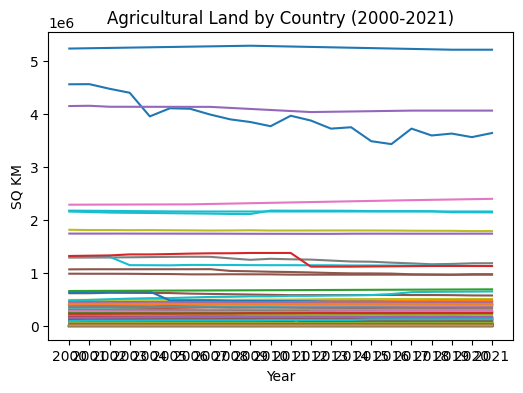

In [799]:
# Using df_AG_LND_AGRI_K2, Agricultural Land by Country (2000-2021)
plot_data_series_years (dataframe=df_AG_LND_AGRI_K2, ylabel="SQ KM", title="Agricultural Land by Country (2000-2021)", start=2000, end=2021)

Using the function, I will now plot all the data series in turn to ascertain the shape of the dataset graphically.

In [800]:
data_series_list = list(country_data_df['SeriesCode'].unique())
print (f"Dataseries ({len(data_series_list)}): {data_series_list}")

Dataseries (87): ['AG.LND.AGRI.K2', 'AG.LND.AGRI.ZS', 'AG.LND.ARBL.ZS', 'AG.LND.EL5M.UR.K2', 'AG.LND.EL5M.UR.ZS', 'AG.LND.EL5M.ZS', 'AG.LND.FRST.K2', 'AG.LND.IRIG.AG.ZS', 'AG.LND.PRCP.MM', 'SP.POP.TOTL', 'SP.URB.TOTL', 'SP.URB.TOTL.IN.ZS', 'BX.KLT.DINV.WD.GD.ZS', 'SH.MED.CMHW.P3', 'EG.ELC.NGAS.ZS', 'EG.ELC.NUCL.ZS', 'EG.ELC.PETR.ZS', 'EG.ELC.RNEW.ZS', 'EG.ELC.RNWX.KH', 'EG.ELC.RNWX.ZS', 'EG.FEC.RNEW.ZS', 'EG.USE.ELEC.KH.PC', 'EN.ATM.CO2E.KT', 'EN.ATM.CO2E.LF.KT', 'EN.ATM.CO2E.SF.KT', 'EN.ATM.GHGO.KT.CE', 'EN.ATM.GHGO.ZG', 'EN.ATM.GHGT.KT.CE', 'EN.ATM.GHGT.ZG', 'EN.ATM.METH.KT.CE', 'EN.ATM.NOXE.KT.CE', 'EN.ATM.PFCG.KT.CE', 'EN.ATM.SF6G.KT.CE', 'EN.CLC.MDAT.ZS', 'EN.POP.EL5M.RU.ZS', 'EN.POP.EL5M.UR.ZS', 'ER.H2O.FWTL.K3', 'ER.H2O.FWTL.ZS', 'ER.LND.PTLD.ZS', 'ER.PTD.TOTL.ZS', 'NV.AGR.TOTL.ZS', 'AG.LND.ARBL.HA', 'AG.SRF.TOTL.K2', 'AG.LND.TOTL.UR.K2', 'AG.LND.TOTL.K2', 'AG.LND.TOTL.RU.K2', 'EN.ATM.METH.AG.KT.CE', 'EN.ATM.NOXE.AG.KT.CE', 'EN.ATM.CO2E.GF.KT', 'EN.ATM.CO2E.EG.ZS', 'EN.ATM.METH.

In [801]:
# NB run time approx: 55 sec

def get_unit (dataframe):
    return str(dataframe["Unit"].unique()[0])

def get_seriesname (dataframe):
    return str(dataframe["Series"].unique()[0])

for _series in data_series_list:
    _series_data = country_data_df.loc[country_data_df['SeriesCode'] == _series]
    _unit = get_unit(_series_data)
    _series_name = get_seriesname (_series_data)
    _title = str(_series_name + "(" +_unit+ ")")
    #plot_data_series_years (dataframe=_series_data, title=_title, ylabel=_unit)

This is clearly an unsuitable plot for clearly showing this data, (even using logarithmic values). However, these plots how the general 'shape' of the data sets for future reference. It will be useful to add a units column to each series.

Regional Plots

In [805]:
subregion_gb = countries_df.groupby(by=['Subregion'])

# Show link between region and subregion
print (subregion_gb.Region.unique())



Subregion
Antarctica                   [Antarctica]
Australia and New Zealand       [Oceania]
Caribbean                      [Americas]
Central America                [Americas]
Central Asia                       [Asia]
Eastern Africa                   [Africa]
Eastern Asia                       [Asia]
Eastern Europe                   [Europe]
Melanesia                       [Oceania]
Micronesia                      [Oceania]
Middle Africa                    [Africa]
Northern Africa                  [Africa]
Northern America               [Americas]
Northern Europe                  [Europe]
Polynesia                       [Oceania]
South America                  [Americas]
South-eastern Asia                 [Asia]
Southern Africa                  [Africa]
Southern Asia                      [Asia]
Southern Europe                  [Europe]
Western Africa                   [Africa]
Western Asia                       [Asia]
Western Europe                   [Europe]
Name: Region, dtype: obj

In [843]:
fig = px.choropleth(country_data_df, locations='ISOcode', color='Subregion', hover_name='Subregion',
                    projection='equirectangular', title='Sub-region Groupings')
fig.show()

In [860]:
# Extract C02 data for all, then extract westrn european figures
co2data_df = country_data_df.loc[country_data_df['SeriesCode'] == 'EN.ATM.CO2E.KT'] 
#western_europe_co2_df = co2data_df.loc[co2data_df['Subregion'] == "Western Europe"]
#northern_europe_co2_df = co2data_df.loc[co2data_df['Subregion'] == "Northern Europe"]

Extract Totals for CO2 by Region

In [861]:

print (co2data_df.groupby(by='Subregion')[numerical_fields].sum())



                                   2000          2001          2002  \
Subregion                                                             
Australia and New Zealand  3.688778e+05  3.772282e+05  3.848589e+05   
Caribbean                  7.341630e+04  7.443750e+04  7.675900e+04   
Central America            4.136608e+05  4.163854e+05  4.239678e+05   
Central Asia               2.893083e+05  2.883739e+05  3.094650e+05   
Eastern Africa             4.148008e+04  4.201305e+04  4.146996e+04   
Eastern Asia               5.059008e+06  5.241450e+06  5.544720e+06   
Eastern Europe             2.566520e+06  2.580695e+06  2.566739e+06   
Melanesia                  3.986480e+03  4.762900e+03  4.824600e+03   
Micronesia                 6.251000e+02  6.114000e+02  6.132000e+02   
Middle Africa              3.626158e+04  3.686819e+04  3.456760e+04   
Northern Africa            2.990221e+05  3.143057e+05  3.247726e+05   
Northern America           6.290022e+06  6.254878e+06  6.117378e+06   
Northe

In [ ]:
# Plot this



Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| country_data_df| Country,Code,SeriesCode,{Data Values} | Pandas DF |
| regional_data_only_df | Country,Code,SeriesCode,{Data Values} | Pandas DF |


## Task 2 - Data Analysis


Task 2. Data analysis (LO2, LO3)
Formulate data analysis questions which could be answered by analysing your chosen dataset. For each question provide graph/chart along with your own interpretation. Please find the sample data analysis questions formulated for the ONS census dataset.

### Task Questions

- Describe the relationship between type of agricultural land use and CO2 emmissions, by country.
- Which type of land usage generates the most CO2?
- Describe the change is land use by country, and by world region.
- Describe trends in land use by region.
- Predict how countries CO2 emmissions will trend.
- Does the region of the world collerate to Co2 emmissions?
- Is there a link to age and or gender to CO2 emmissions?
- Which region of the world generates the most CO2?

CO2 Emissions Data

EN.ATM.CO2E.KT



In [ ]:


df_EN_ATM_CO2E_KT = country_data_df.loc[country_data_df['SeriesCode'] == 'EN.ATM.CO2E.KT']

fig = px.choropleth(df_EN_ATM_CO2E_KT, locations='ISOcode', color='2019', hover_name='Country',
                    projection='natural earth', title='CO2 Emissions by Country 2019')
fig.show()


Playing with charts

In [ ]:
# Plot graph of birth and death rates on a world map



df_SP_DYN_CDRT_IN = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.DYN.CDRT.IN']
df_SP_DYN_CBRT_IN = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.DYN.CBRT.IN']

_range = [str(x).zfill(2) for x in range(2000,2021+1)]
_years = pd.Index(_range)



fig = go.Figure(go.Scatter(x=df_SP_DYN_CBRT_IN['2021'], y=df_SP_DYN_CDRT_IN['2021'], text=df_SP_DYN_CDRT_IN.Country, mode='markers'))
#fig.update_xaxes(title_text='GDP per Capita', type='log')
#fig.update_yaxes(title_text='Life Expectancy')
py.iplot(fig, filename='pandas-multiple-scatter')